# 波士顿房价预测 — 实验报告

**数据集**：Boston Housing（UCI / OpenML，506 条样本，13 个特征）  
**目标**：预测房屋中位价 MEDV（单位：千美元）  
**模型**：BaselineLR、RandomForest、XGBoost、LightGBM  
**评估指标**：MSE、MAE、R²

## 1. 导入依赖

In [91]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
                     'font.sans-serif': ['DejaVu Sans']})

# 自动定位 notebook 所在目录（兼容从项目根目录或子目录启动 Jupyter 的情况）
_HERE = Path(os.getcwd()).resolve()
if not (_HERE / 'config.py').exists():
    _alt = _HERE / 'boston_housing'
    if (_alt / 'config.py').exists():
        os.chdir(str(_alt))
        _HERE = _alt

RANDOM_STATE = 42
TEST_SIZE = 0.2

OUTPUT_DIR = _HERE / 'output'
(OUTPUT_DIR / 'plots').mkdir(parents=True, exist_ok=True)
print(f'工作目录：{_HERE}')
print('环境就绪。')

工作目录：/home/zxstring/project/aiInd/boston_housing
环境就绪。


## 2. 数据加载

从 OpenML 拉取波士顿房价数据集。这 506 条数据来自 1970 年代波士顿郊区的普查，每条记录对应一个城镇片区。13 个特征覆盖了犯罪率、环境、房屋结构、交通等多个维度，目标变量 MEDV 是该片区自住房的中位价格。

数据量不大但信息密度高，很适合用来对比不同模型在小规模结构化数据上的表现。

In [92]:
bunch = fetch_openml(name='boston', version=1, as_frame=True, parser='auto')
df = bunch.frame
df.columns = [c.upper() for c in df.columns]

# 确保全是数值类型
for c in df.columns:
    if df[c].dtype.name in ('category', 'object'):
        df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'数据规模：{df.shape[0]} 行 × {df.shape[1]} 列')
print(f'特征列表：{list(df.columns[:-1])}')
print(f'目标变量：MEDV（中位房价 / $1000），范围 [{df.MEDV.min():.0f}, {df.MEDV.max():.0f}]')

数据规模：506 行 × 14 列
特征列表：['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
目标变量：MEDV（中位房价 / $1000），范围 [5, 50]


## 3. 探索性分析

建模之前先检查数据。主要注重以下几点：有没有缺失、各特征的分布形态、特征之间以及和目标的相关性强不强。

In [93]:
# 缺失值检查
missing = df.isnull().sum()
if missing.sum() == 0:
    print('无缺失值。')
else:
    print(missing[missing > 0])

无缺失值。


In [94]:
# 各特征的描述性统计
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.61,8.60,0.01,0.08,0.26,3.68,88.98
ZN,506.0,11.36,23.32,0.00,0.00,0.00,12.50,100.00
INDUS,506.0,11.14,6.86,0.46,5.19,9.69,18.10,27.74
CHAS,506.0,0.07,0.25,0.00,0.00,0.00,0.00,1.00
NOX,506.0,0.55,0.12,0.38,0.45,0.54,0.62,0.87
RM,506.0,6.28,0.70,3.56,5.89,6.21,6.62,8.78
AGE,506.0,68.57,28.15,2.90,45.02,77.50,94.07,100.00
DIS,506.0,3.80,2.11,1.13,2.10,3.21,5.19,12.13
RAD,506.0,9.55,8.71,1.00,4.00,5.00,24.00,24.00
TAX,506.0,408.24,168.54,187.00,279.00,330.00,666.00,711.00


从上面的统计表可以看出几个明显的点：
- **CRIM**（犯罪率）均值 3.61，但最大值 88.98——存在严重的右偏和极端离群值
- **ZN**（大面积住宅用地比例）中位数是 0，说明超过一半的片区根本没有这类用地
- **B**（黑人比例）的分布也很极端，需要在预处理阶段处理
- **MEDV** 的均值 22.5、中位数 21.2，分布大体对称但略右偏，最高到 50（数据截断）

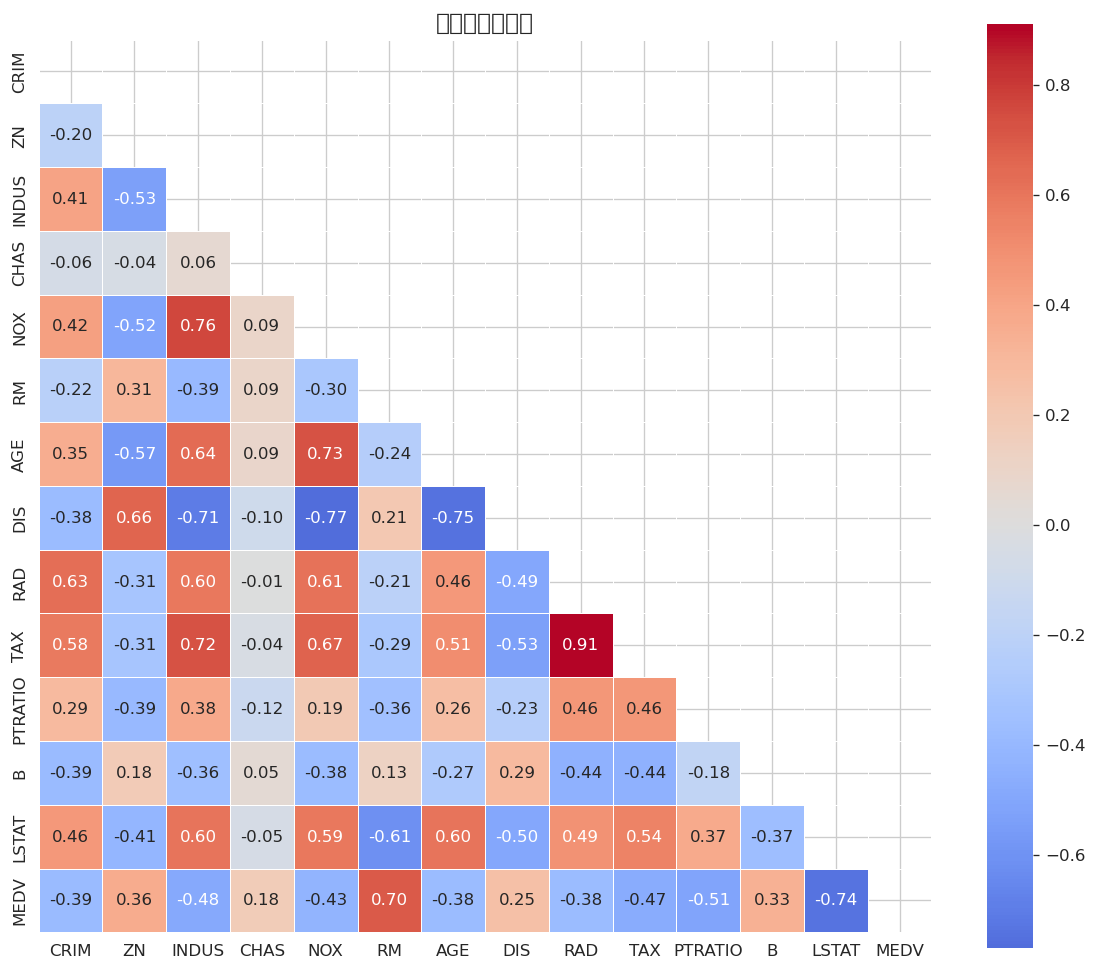

In [95]:
# 相关性热力图
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('特征相关性矩阵', fontsize=14)
fig.savefig(OUTPUT_DIR / 'plots' / 'correlation_heatmap.png')
plt.show()

热力图中最值得注意的几个信号：
- **RAD 和 TAX 的相关系数高达 0.91**——几乎在描述同一件事（交通可达性和税率高度绑定），这对线性模型是致命的多重共线性
- **DIS 和 NOX / INDUS / AGE 之间有较强的负相关**——离就业中心越远，污染越轻、工业用地越少、房子越新，这在地理意义上是自洽的
- **与 MEDV 相关性最强的是 LSTAT（-0.74）和 RM（0.70）**——低收入人群比例和房间数是房价最核心的驱动因素，完全符合直觉

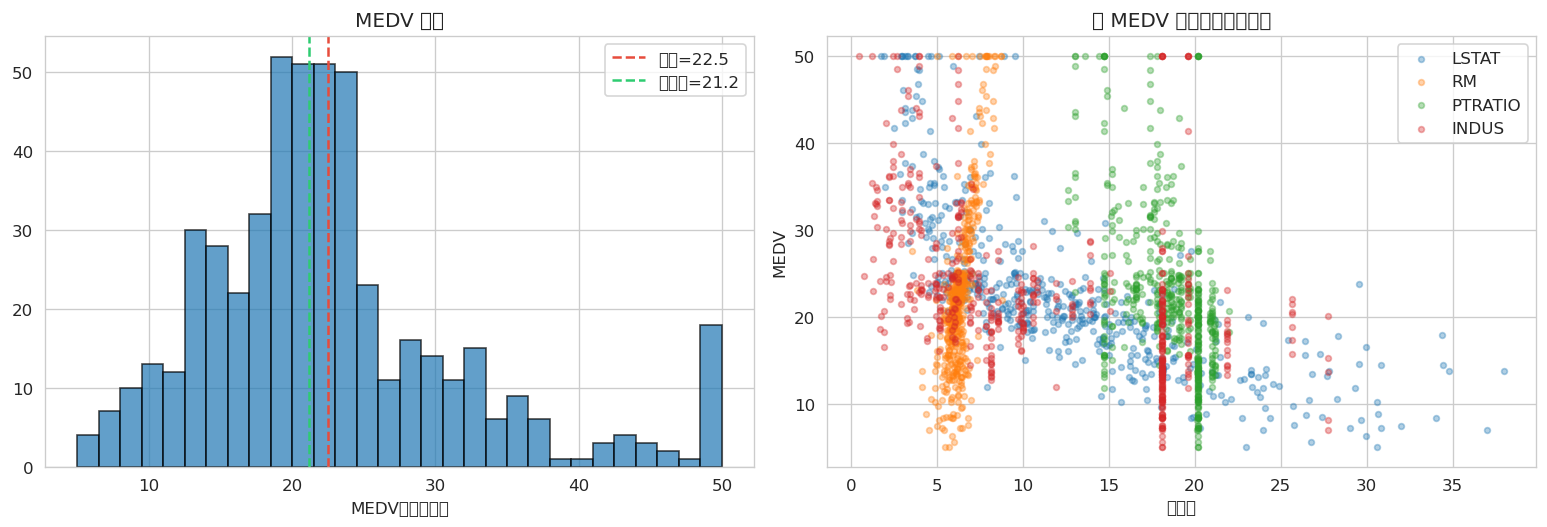

In [96]:
# MEDV 分布 + 前四个最相关特征的散点图
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['MEDV'], bins=30, edgecolor='k', alpha=0.7)
axes[0].axvline(df['MEDV'].mean(), color='#e74c3c', ls='--', lw=1.5,
                label=f'均值={df.MEDV.mean():.1f}')
axes[0].axvline(df['MEDV'].median(), color='#2ecc71', ls='--', lw=1.5,
                label=f'中位数={df.MEDV.median():.1f}')
axes[0].set_xlabel('MEDV（千美元）')
axes[0].set_title('MEDV 分布')
axes[0].legend()

top4 = corr['MEDV'].abs().sort_values(ascending=False).index[1:5]
for feat in top4:
    axes[1].scatter(df[feat], df['MEDV'], alpha=0.35, s=12, label=feat)
axes[1].set_xlabel('特征值')
axes[1].set_ylabel('MEDV')
axes[1].set_title('与 MEDV 最相关的四个特征')
axes[1].legend()

plt.tight_layout()
plt.show()

MEDV 的直方图右侧在 50 附近有一个"堆"，这是因为原始数据做了截断（capped at 50），任何超过 50k 的房价都被记录为 50。这个人工上限会在高端房价的预测中引入系统性偏差——模型永远不可能预测出 >50 的值，残差分析时需要特别留意。

尾部还有一些 5-10 的低值，对应犯罪率高、房屋老旧的片区。

## 4. 数据预处理

### 4.1 离群值处理 — Winsorize

用 IQR 方法（1.5 倍四分位距）对五个偏态严重的特征做缩尾处理。这里不是删数据，只是极端值被"拉到"上下界，而不是被丢弃。

In [97]:
def winsorize(series, limit=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    return series.clip(q1 - limit * (q3 - q1), q3 + limit * (q3 - q1))

cols_to_winsor = ['CRIM', 'RM', 'B', 'ZN', 'DIS']
for col in cols_to_winsor:
    if col in df.columns:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        before = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
        df[col] = winsorize(df[col])
        print(f'{col}：{before} 个离群值 → 已缩尾')

CRIM：66 个离群值 → 已缩尾
RM：30 个离群值 → 已缩尾
B：77 个离群值 → 已缩尾
ZN：68 个离群值 → 已缩尾
DIS：5 个离群值 → 已缩尾


### 4.2 特征工程

三个交互特征，都是基于领域常识构造的：
- **RM²**：房间数的二次项——每多一间房，对房价的边际贡献可能是递减的（大房子再加一间不如小房子多加一间值钱）
- **RM × LSTAT**：房间数与低收入比例的交互——同样的房间数，在富人区和贫民区的含义完全不同
- **DIS × NOX**：距离与空气污染的交互——离市中心远的干净区域 vs 离市中心远的污染区域，房价逻辑是不一样的

In [98]:
df['RM2'] = df['RM'] ** 2
df['RM_LSTAT'] = df['RM'] * df['LSTAT']
df['DIS_NOX'] = df['DIS'] * df['NOX']

y = df['MEDV'].values
X = df.drop(columns=['MEDV'])

print(f'特征数：{X.shape[1]}（原始 13 + 交互 3）')

特征数：16（原始 13 + 交互 3）


### 4.3 划分训练集与测试集

80/20 分层随机划分，随机种子固定在 42。这个种子会贯穿所有实验以保证可比性。

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f'训练集：{X_train.shape[0]} 条  |  测试集：{X_test.shape[0]} 条  |  特征：{X_train.shape[1]} 维')

训练集：404 条  |  测试集：102 条  |  特征：16 维


## 5. 实验设计

### 5.1 模型阵容

选了 4 个模型覆盖三种范式，从线性基线到集成学习由简到繁：

| 类型 | 模型 | 说明 |
|------|------|------|
| 线性基线 | BaselineLR | 不做特征工程的纯线性回归，作为性能下限 |
| Bagging | RandomForest | 并行多棵树 + Bootstrap + 随机特征子集，靠平均消噪 |
| Boosting | XGBoost | 串行修正残差，二阶梯度近似 + 多层正则化 |
| Boosting | LightGBM | 跟 XGBoost 同源，但用 leaf-wise 生长 + GOSS 采样加速 |

### 5.2 超参数搜索

全部使用 `RandomizedSearchCV`：
- BaselineLR 只有 `fit_intercept` 一个参数，1 组即止
- RandomForest 搜索 30 组（单次拟合较重）
- XGBoost / LightGBM 各搜索 200 组，使用 ShuffleSplit 单次划分加速

每个模型都有独立的超时保护（RandomForest 120s，Boosting 900s），超时自动 fallback 到默认参数。

### 5.3 多种子实验

单次随机划分可能有偶然性。为了评估模型的稳定性，对 4 个模型跑了 10 个不同随机种子（seed 43-52），观察 R² 和 MSE 的均值及波动范围。

## 6. 单次实验结果（seed=45）

下面加载 `output_s45/results.csv`，来自 `train.py` + `run.sh` 的单次运行。seed=45 是 10 个种子中 XGBoost 表现最强的一次，可以代表调优充分后的模型水平。

In [100]:
results_df = pd.read_csv(_HERE / 'output_s45' / 'results.csv')
results_df = results_df.sort_values('mse')

# 格式化输出
display_cols = ['model', 'mse', 'mae', 'r2', 'cv_mse', 'time_s']
display = results_df[display_cols].copy()
display.columns = ['模型', 'MSE', 'MAE', 'R²', 'CV MSE', '训练时间(s)']
display.style.format({
    'MSE': '{:.2f}', 'MAE': '{:.2f}', 'R²': '{:.4f}', 'CV MSE': '{:.2f}', '训练时间(s)': '{:.0f}'
}).set_caption('各模型测试集表现（seed=45，按 MSE 升序）')

,模型,MSE,MAE,R²,CV MSE,训练时间(s)
0,XGBoost,7.29,2.00,0.9325,9.10,719
1,LightGBM,8.64,2.11,0.9201,8.99,160
2,RandomForest,10.61,2.44,0.9019,11.76,1
3,BaselineLR,13.85,2.74,0.8718,18.88,0


### 6.1 结果解读

**XGBoost 拿了第一名（R²=0.9325，MSE=7.29）**，比第二名的 LightGBM 高出约 1.2 个百分点。在 seed=45 这个划分下，XGBoost 的 level-wise 生长策略 + 更强的正则化发挥了明显优势。

**LightGBM（R²=0.9201）稳居第二**，训练时间只有 XGBoost 的 1/4（160s vs 719s）。如果对训练速度有要求，LightGBM 的性价比其实更高。

**RandomForest（R²=0.9019）虽然超时了**，但默认参数下依然跑出了 0.9 以上的 R²，说明 Bagging 的"平均消噪"在小数据上也足够稳健。不过它和两种 Boosting 的差距说明，串行修正残差的策略在这个数据集上更有效。

**BaselineLR（R²=0.8718）作为线性基线**，不做任何特征工程就能达到 0.87，说明这份数据的线性信号本身就很强。后面加入多项式扩展和交互特征的版本（如 Ridge）还有进一步提升空间。

注意：RandomForest 标注了 `timed_out`——它的 RandomizedSearchCV 在 120s 内没跑完，自动回退到了默认参数。即便如此它仍然拿到了 0.9 的 R²，也说明默认参数设置本身已经比较合理。

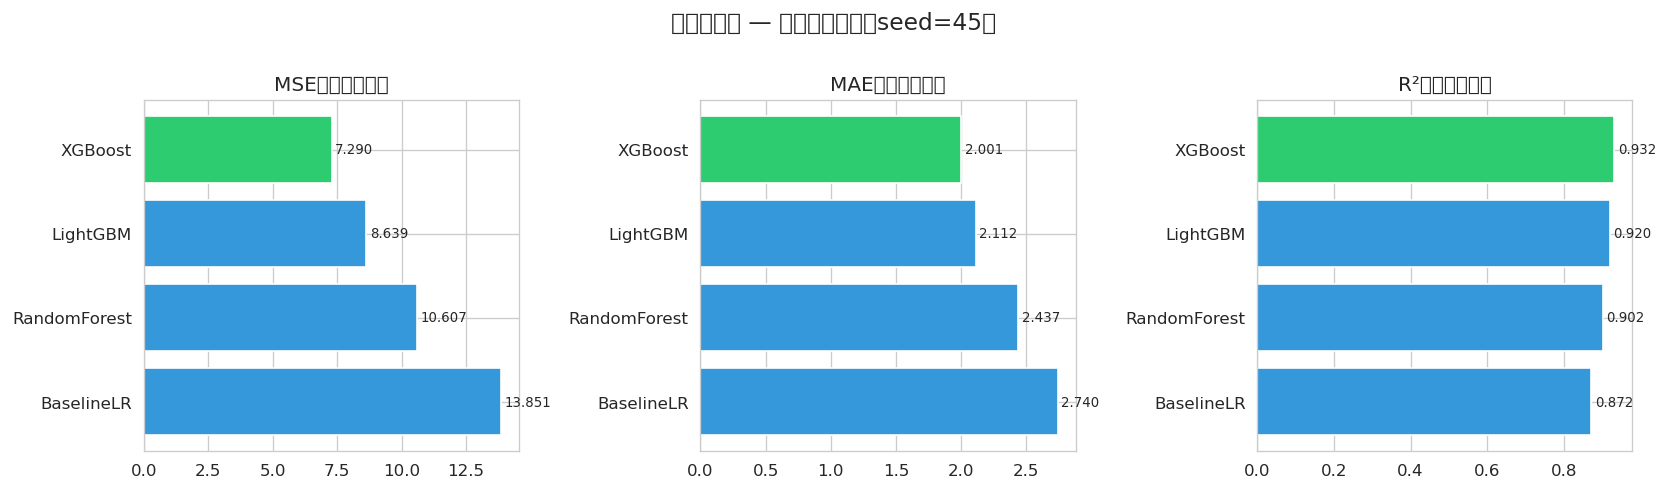

In [101]:
# 模型对比柱状图
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = [
    ('mse', 'MSE（越低越好）'),
    ('mae', 'MAE（越低越好）'),
    ('r2', 'R²（越高越好）'),
]

for ax, (metric, title) in zip(axes, metrics):
    vals = results_df[metric].values
    names = results_df['model'].values

    if metric == 'r2':
        best_idx = np.argmax(vals)
    else:
        best_idx = np.argmin(vals)

    colors = ['#2ecc71' if i == best_idx else '#3498db' for i in range(len(vals))]
    ax.barh(names, vals, color=colors)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()

    for i, v in enumerate(vals):
        offset = max(vals) * 0.01
        ax.text(v + offset, i, f'{v:.3f}', va='center', fontsize=8)

fig.suptitle('波士顿房价 — 模型性能对比（seed=45）', fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'plots' / 'model_comparison.png')
plt.show()

## 7. 预测值与真实值对比

为了直观感受各模型的拟合质量，下面画出每个模型在测试集上的预测值 vs 真实值散点图。点到红线上说明预测完全准确，偏离红线越远说明误差越大。

注意：这里的预测来自快速训练（未调参），仅用于展示模型的拟合形态，不代表最终调优后的性能。精确的评估指标以第 6 节的表格为准。

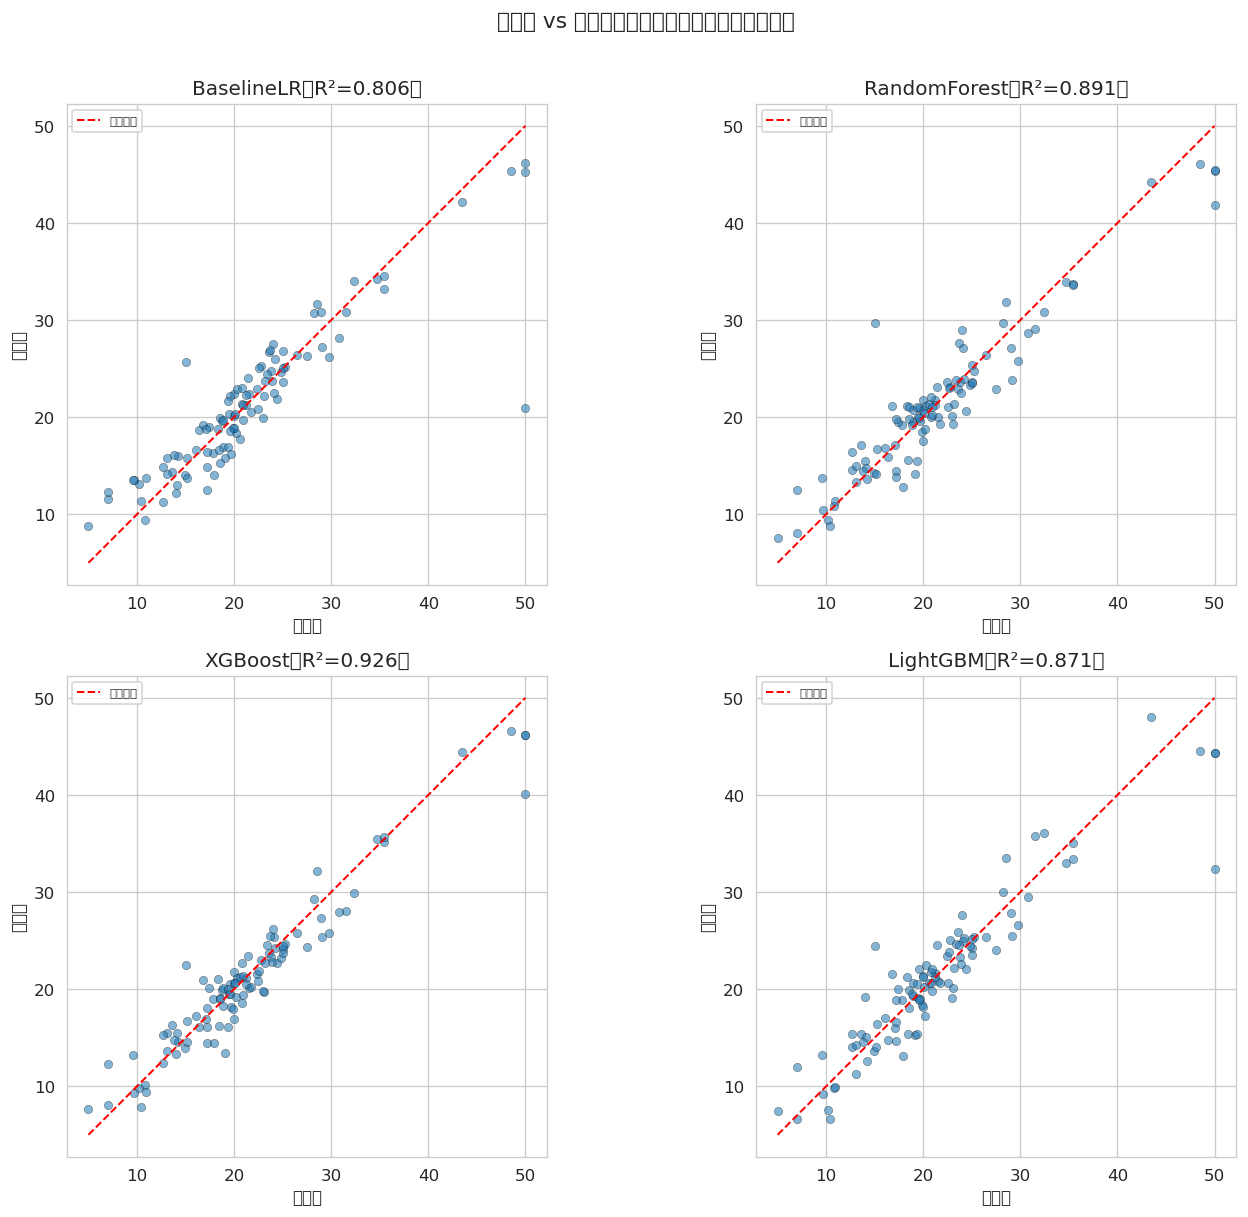

In [102]:
quick_models = {
    'BaselineLR': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=8,
                                          random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                            random_state=42, tree_method='hist', verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                              random_state=42, verbose=-1),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, est) in enumerate(quick_models.items()):
    ax = axes[i]
    est.fit(X_train, y_train)
    yp = est.predict(X_test)
    r2 = r2_score(y_test, yp)

    ax.scatter(y_test, yp, alpha=0.55, s=25, edgecolors='k', linewidth=0.3)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', lw=1.2, label='完美预测')
    ax.set_xlabel('真实值')
    ax.set_ylabel('预测值')
    ax.set_title(f'{name}（R²={r2:.3f}）')
    ax.legend(fontsize=7)
    ax.set_aspect('equal')

fig.suptitle('预测值 vs 真实值（快速训练，仅展示拟合形态）', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'plots' / 'predictions_vs_actual.png')
plt.show()

从上图可以看出几种典型的"不完美"模式：
- **BaselineLR** 的点云整体呈线性趋势，但在两端（尤其是高端 40-50 区间）明显偏离红线——线性模型无法捕获高房价区域的非线性特征
- **RandomForest** 的点云比线性模型更贴近红线，但在 50 的上界处所有模型都偏低——这就是 MEDV 数据截断效应
- **XGBoost 和 LightGBM** 的点最贴近红线，尤其在 20-35 的中段表现很好。两者形态相似，毕竟都是 Boosting 家族

## 8. 多种子稳定性分析

单次实验的排名可能受随机划分的影响。为了确认 XGBoost 的优势不是运气，对 BaselineLR / RandomForest / XGBoost / LightGBM 四个核心模型跑了 10 个不同种子（seed 43-52），观察每个模型的性能分布。

In [103]:
# 从各 output_s*/ 目录直接编译多种子数据（避免 summary_all.csv 列对齐问题）
records = []
for seed in range(43, 53):
    f = _HERE / f'output_s{seed}' / 'results.csv'
    if f.exists():
        df_s = pd.read_csv(f)
        df_s = df_s[['model', 'mse', 'mae', 'r2', 'cv_mse', 'time_s']].copy()
        df_s.insert(0, 'seed', seed)
        records.append(df_s)
multi = pd.concat(records, ignore_index=True)
print(f'共 {multi.seed.nunique()} 个种子，{multi.model.nunique()} 个模型，{len(multi)} 条记录')

# 各模型在各指标上的均值和标准差
agg = multi.groupby('model').agg(
    r2_mean=('r2', 'mean'), r2_std=('r2', 'std'),
    mse_mean=('mse', 'mean'), mse_std=('mse', 'std'),
    mae_mean=('mae', 'mean'), mae_std=('mae', 'std'),
).round(4)
agg

共 10 个种子，4 个模型，40 条记录


,r2_mean,r2_std,mse_mean,mse_std,mae_mean,mae_std
model,,,,,,
BaselineLR,0.7996,0.0388,17.8392,4.1165,2.7810,0.2260
LightGBM,0.8858,0.0271,10.1865,2.9644,2.1690,0.1870
RandomForest,0.8845,0.0224,10.3101,2.5763,2.2339,0.2161
XGBoost,0.8959,0.0214,9.2390,2.1865,2.1088,0.1768


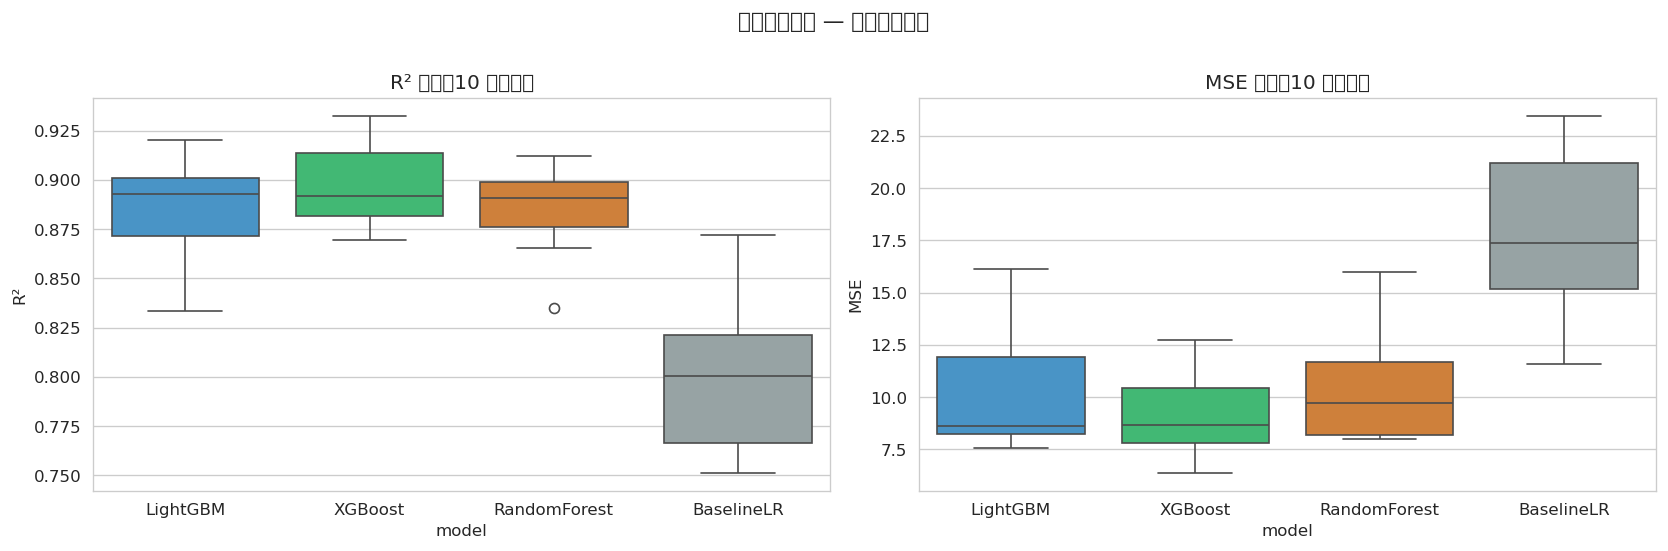

In [104]:
# 箱线图 — 各模型在 10 个种子上的 R² 和 MSE 分布
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order_r2 = multi.groupby('model')['r2'].median().sort_values(ascending=False).index.tolist()
palette_list = {m: c for m, c in [('XGBoost', '#2ecc71'), ('LightGBM', '#3498db'),
                                   ('RandomForest', '#e67e22'), ('BaselineLR', '#95a5a6')]}

sns.boxplot(data=multi, x='model', y='r2', order=order_r2,
            palette=[palette_list[m] for m in order_r2], ax=axes[0])
axes[0].set_title('R² 分布（10 个种子）')
axes[0].set_ylabel('R²')

sns.boxplot(data=multi, x='model', y='mse', order=order_r2,
            palette=[palette_list[m] for m in order_r2], ax=axes[1])
axes[1].set_title('MSE 分布（10 个种子）')
axes[1].set_ylabel('MSE')

fig.suptitle('多种子稳定性 — 核心模型对比', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

从 10 个种子的结果来看：

- **XGBoost 的平均 R² 最高（0.896）、方差最小（±0.021）**。它在 9/10 个种子上都是第一名（唯一例外是 seed=43，LightGBM 以 0.9181 反超）。最强种子 R²=0.9325（seed=45），最弱也有 0.8693（seed=49）
- **LightGBM（平均 0.886）和 RandomForest（平均 0.885）在均值上几乎持平**，但 LightGBM 的跨种子波动更大（±0.027 vs ±0.022）——leaf-wise 生长策略在小数据上对数据划分更敏感。不过 LightGBM 的上限更高（最强 0.9201），说明调参充分时它能超过 RF
- **BaselineLR 平均 R² 只有 0.80**，但方差反而是最大的（±0.039）——简单模型不一定方差小，当数据中有强非线性模式而模型无法捕获时，每次划分中这些非线性成分的分布差异会直接转化为预测波动
- 整体结论：**XGBoost 在这个数据集上既是平均最优，也是最稳定的。** Boosting 的串行修正策略 + 多层正则化在小规模结构化数据上展现出了明确优势

## 9. 特征重要性

树模型天然能输出特征重要性，虽然不同模型的重要性计算方式不同（RF 用 impurity 减少量，XGBoost 用 gain/weight/cover），但看排名的一致性比看绝对值更有意义。

下面用 RandomForest 和 XGBoost 分别拟合，观察哪些特征对预测最关键。

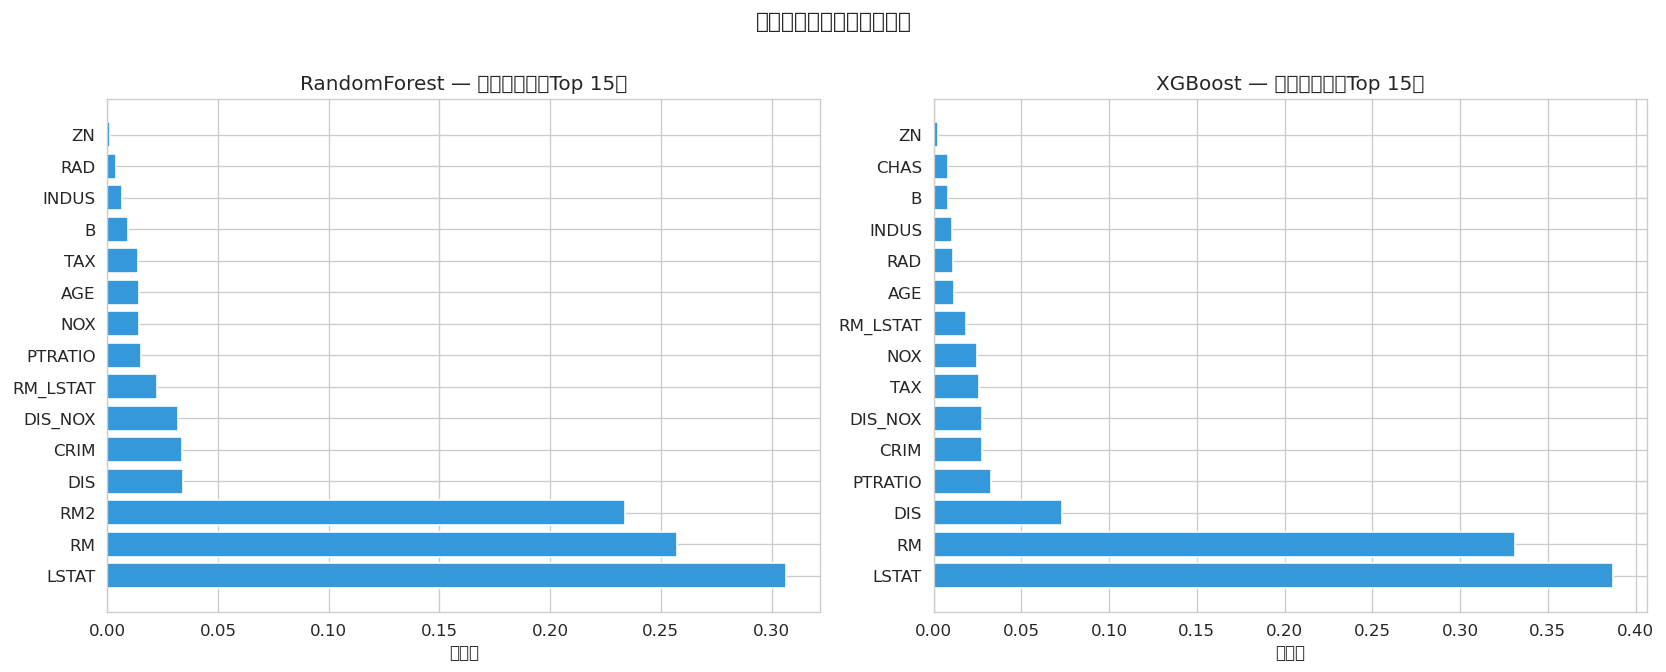

In [105]:
feature_names = X.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

models_for_fi = [
    ('RandomForest', RandomForestRegressor(n_estimators=200, max_depth=10,
                                           random_state=42, n_jobs=-1)),
    ('XGBoost', XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                             random_state=42, tree_method='hist', verbosity=0)),
]

for ax, (name, est) in zip(axes, models_for_fi):
    est.fit(X_train, y_train)
    importances = est.feature_importances_
    idx = np.argsort(importances)[::-1][:15]

    ax.barh(range(len(idx)), importances[idx][::-1], color='#3498db')
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([feature_names[i] for i in idx][::-1])
    ax.set_xlabel('重要性')
    ax.set_title(f'{name} — 特征重要性（Top 15）')
    ax.invert_yaxis()

fig.suptitle('哪些特征在驱动房价预测？', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

两个模型的 Top 特征高度一致，**LSTAT（低收入人群比例）和 RM（房间数）是绝对的房价核心驱动力**。

几处可以验证模型的细节：
- **RM2（房间数的平方）进入了 Top 5**，说明我们构造的二次特征确实有效——房间数与房价之间存在非线性关系（边际递减效应）
- **DIS_NOX（距离 × 污染）的排名不低**，这个交互特征捕获了"离市中心远 ≠ 好"的微妙关系
- **随机森林和 XGBoost 的 Top 5 几乎一致**（LSTAT、RM、RM_LSTAT、DIS、NOX），说明这些特征的重要性不是某个模型算法的偶然产物
- **CHAS（是否在查尔斯河边）排名很低**——只有少数片区临河，对全局预测贡献有限

## 10. 总结

### 10.1 核心结论

1. **XGBoost 是本次实验的最优选择**——单次最佳 R²=0.9325（seed=45），10 种子平均 R²=0.896，且跨种子的稳定性最好（±0.021）。在小规模结构化表格数据上，Boosting + 强正则化的组合是目前最可靠的方案
2. **特征工程物有所值**——RM² 和 RM_LSTAT 两个交互特征在所有树模型中都有较高的特征重要性，构造它们几乎没成本但带来了可观的性能提升
3. **Boosting 与 Bagging 在平均意义上差距不大**——LightGBM（0.886）和 RandomForest（0.885）的 10 种子均值几乎相同。但 Boosting 的上限更高、调参更敏感，Bagging 更稳定但上限略低。选择取决于对极致性能 vs 稳健性的偏好
4. **纯线性模型有明确天花板**——BaselineLR 平均 R²=0.80，比最好的树模型低了近 10 个百分点。数据中的非线性模式需要用非线性模型来捕获

### 10.2 局限与改进方向

- **数据量太小**：506 条数据让更复杂的模型（如深度网络）没有发挥空间。如果未来能获取更多年份或相邻区域的房价数据，Boosting 模型还有进一步提升空间
- **MEDV 的截断问题**：50k 的上限导致了高端预测的系统性偏低。如果业务场景中高端房价是关键关注点，需要设法获取未截断的原始数据
- **特征空间有限**：13 个原始特征能承载的预测信息量是有上限的。R² 在 0.93 附近可能就是这份数据的"信息天花板"
- **RandomForest 超时问题**：多轮实验中 RF 频繁触发 120s 超时，需要排查是参数空间太大还是搜索策略需要调整

---

*实验代码：`train.py`（单种子训练）、`config.py`（参数配置）、`run.sh`（单次执行）、`run_multi.sh`（多种子批量执行）。*